<a href="https://colab.research.google.com/github/VildanaRazumova/thesis-demand-forecasting/blob/main/thesis_notebook_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand-Based Dynamic Pricing Models for Travel Markets

---

# The following Project information



**Client:** A leading B2B tour operator in Kazakhstan and Central Asia, cooperating with 5,000+ travel agencies across destinations including Vietnam, Thailand, Egypt, Turkey, UAE and the Maldives

**Problem statement & Importance:**
Tour operators in B2B travel markets must commit to flight and hotel inventory 6-8 months in advance, without knowing the actual demand. Traditional demand estimation methods rely on historical bookings and expert judgment, which becomes insufficient when market conditions shift due to competitor pricing, seasonal search trends, and external events. This uncertainty leads to either unsold seats or missed revenue opportunities. A critical business challenge is not only whether demand can be predicted accurately, but also how early in the booking window a reliable prediction can be made, giving the operator enough time to act.

**Goal:**
This study focuses on the Kazakhstan - Vietnam route as a pilot, as Vietnam is the operator's most popular destination and each route has unique demand patterns, seasonality, and external signals.


**Methodology:**
The methodology is designed to be scalable and applicable to other destinations in subsequent research.

The primary objective is to develop and evaluate machine learning models that predict flight load factor at multiple booking windows (D-90, D-60, D-30, D-7), using a multivariate feature set constructed from internal booking signals at each point in time.

The study additionally assesses whether external market signals improve prediction accuracy beyond internal booking data alone, and identifies the earliest booking window at which reliable load factor predictions can be made to support dynamic pricing decisions.

---

Load Factor = Seats Sold / Total Seats x 100%

---

**Business Benefits:**
1. Identifies the earliest reliable prediction window
2. Reduces financial risk from unsold charter seats
3. Provides a data-driven foundation for dynamic price decisions
4. Competitive advantage over operators using rule-based pricing only

**Relevant data collected from:**

Historical Internal signals (2024-2026):
-  booking claims: lead time, pax, hotel & flight costs
-  flight capacity: seats sold, empty seats, load factor per window

External signals at specific points in the past:
- Google Trends API: search interest per destination
- Google News API: news per country
- Public holiday calendars: event & holiday flags

**Approach:**

A time-series approach is used throughout this project. Features are constructed at each booking window using only information available at that point in time, preventing data leakage and ensuring realistic future deployment.

**Core Task: Load Factor Prediction at multiple booking windows**

| Window | Days Before Departure | Business Meaning |
|--------|----------------------|------------------|
| D-90 | 90 days | Early signal: low booking activity |
| D-60 | 60 days | Search trends become informative |
| D-30 | 30 days | Majority of bookings visible |
| D-7  | 7 days  | Final occupancy picture |

Two experiments are conducted:
- Baseline model: internal features only (Linear Regression)
- Extended model: internal + external signals (Random Forest, XGBoost, LightGBM)

# Project Pipeline

This project will be approached through the following steps:

1. **Importing the Libraries**: loading all required Python packages
   for data analysis, visualisation and machine learning

2. **Importing the Data**: loading claims and flight load history
   datasets from Google Drive

3. **Claims Data Overview & Flights Data Overview**: understanding the structure, shape, date ranges
   and column descriptions of both datasets

4. **Exploratory Data Analysis (EDA)**: analysing demand patterns,
   seasonality, lead time distribution and booking window behaviour
   for Vietnam routes

5. **Data Preprocessing**: filter by departure date, route match, quality filters

6. **Joint Analysis and Booking Curve Reconstruction**: Linking claims to flights via FreightID + BlockDate to reconstruct booking curve. Three-step join with 1 day timezone tolerance

7. **Feature Engineering**: constructing internal features (booking
   pace, lead time) and external signals
   (price ratio, search trends, holidays) at each booking window
   (D-90, D-60, D-30, D-7)

8. **Model Building**: training baseline models (internal features
   only) and extended models (internal + external features) using
   Linear Regression, Random Forest, XGBoost and LightGBM

9. **Model Evaluation**: comparing model performance across booking
   windows using MAPE, MAE, RMSE and R2

10. **Conclusion** identifying the earliest booking window at which the model achieves reliable load factor predictions, quantifying the improvement from adding external signals, and discussing implications for dynamic pricing decisions in B2B charter tourism.

# 1. Importing the Libraries

In [220]:
# Import Libraries
from google.colab import drive

# Data libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from pandas.plotting import autocorrelation_plot

# 2. Import the Data

In [221]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load Claims

In [222]:
df_claims = pd.read_csv(
    '/content/drive/MyDrive/Thesis_RazumovaV_2026/thesis_data/dp_claims_features.csv'
)

In [223]:
df_claims.head(3)

,snapshot_date,snapshot_ts_utc,ClaimID,TourID,StatusID,StatusName,IsCancelled,ClaimCreatedDT_UTC,raw_event_time_utc,DepartureDT,...,FlightPartnerID_Fwd,FlightPartner_Fwd,FlightPartnerID_Bck,FlightPartner_Bck,FlightCost_Fwd,FlightCost_Bck,RevisionAmount_Fwd,RevisionAmount_Bck,CurrencyClaimID,CurrencyAlias
0,2026-03-17,2026-03-17 16:54:25,8211917,23966,1,Paid,0,2024-05-21 11:00:00,2024-05-21 11:00:00,2024-08-01,...,157575,SCAT,157575,SCAT,944.16,704.16,120.0,0.0,2,USD
1,2026-03-17,2026-03-17 16:54:25,8456807,23966,1,Paid,0,2024-07-19 10:52:00,2024-07-19 10:52:00,2024-08-01,...,157575,SCAT,157575,SCAT,974.16,704.16,135.0,0.0,2,USD
2,2026-03-17,2026-03-17 16:54:25,8433696,23966,1,Paid,0,2024-07-14 14:59:00,2024-07-14 14:59:00,2024-08-03,...,194333,VietJet,194333,VietJet,1726.52,776.52,475.0,0.0,2,USD


### Load Flights

In [224]:
df_flights = pd.read_csv(
    '/content/drive/MyDrive/Thesis_RazumovaV_2026/thesis_data/dp_flight_load_history.csv',
    on_bad_lines='skip'
)

In [225]:
df_flights.head(3)

,snapshot_date,snapshot_ts_utc,FreightID,FlightName,BlockDate,IsReturn,AirlinePartnerID,AirlineName,FlightClassID,ClassAlias,...,IsOnRequest,Seats_gross,Sold_gross,Empty,Seats_net,Sold_net,BlockRecords,TotalDaysInSale,ResourceCount,last_stamp
0,2026-03-17,2026-03-17 16:54:53,10670,VSV5208,2024-01-01,1,157575,SCAT (),2,Y,...,0,183,2,181,183,2,1,157,1,46013423911
1,2026-03-17,2026-03-17 16:54:53,11538,VJ61,2024-01-01,1,194333,VietJet Air,2,Y,...,0,30,0,30,30,0,1,137,1,46010971579
2,2026-03-17,2026-03-17 16:54:53,12523,VSV5319,2024-01-01,1,157575,SCAT (),2,Y,...,0,30,6,24,30,6,1,52,1,46012591950


# 3.1. Claims Data Overview

1. General Overview
2. Data types
3. Check duplicates
4. Booking Status Distribution
5. Basic Statistics

In [226]:
# 1. General Overview
print(f'Rows: {df_claims.shape[0]:,}')
print(f'Columns: {df_claims.shape[1]}')
print(f'Booking date: {df_claims["ClaimCreatedDT_UTC"].min()} - {df_claims["ClaimCreatedDT_UTC"].max()}')
print(f'Departure: {df_claims["DepartureDT"].min()} - {df_claims["DepartureDT"].max()}')
print(f'Destination: {df_claims["CountryName"].unique()}')
print(f'Missing: {df_claims.isnull().sum().sum()}')

Rows: 37,674
Columns: 64
Booking date: 2023-09-05 11:57:00 - 2026-03-04 08:15:00
Departure: 2024-01-01 - 2026-03-05
Destination: ['Vietnam']
Missing: 145


In [227]:
# Misssing Values in details
df_claims.isnull().sum()[df_claims.isnull().sum() > 0]

,0
HotelName,29
MealName,29
RoomTypeName,29
AccommodationName,29
HotelRegion,29


In [228]:
df_claims[df_claims['HotelName'].isnull()]['TourTypeName'].value_counts()

,count
TourTypeName,
Dynamic package,24
Beach Tours,5


In [229]:
# Check booked AFTER departure
print(f"Negative lead times: {(df_claims['LeadTimeDays'] < 0).sum()}")
print(f"Zero lead times: {(df_claims['LeadTimeDays'] == 0).sum()}")

Negative lead times: 0
Zero lead times: 27


In [230]:
# 2. Data types
df_claims.dtypes

,0
snapshot_date,object
snapshot_ts_utc,object
ClaimID,int64
TourID,int64
StatusID,int64
...,...
FlightCost_Bck,float64
RevisionAmount_Fwd,float64
RevisionAmount_Bck,float64
CurrencyClaimID,int64


In [231]:
# 3. Check duplicates
print(f'Duplicate ClaimIDs:  {df_claims["ClaimID"].duplicated().sum()}')
print(f'Duplicate rows:      {df_claims.duplicated().sum()}')

Duplicate ClaimIDs:  0
Duplicate rows:      0


In [232]:
# 4. Booking Status Distribution
print(df_claims['StatusName'].value_counts())

StatusName
Paid      37665
Unpaid        9
Name: count, dtype: int64


In [233]:
print(df_claims['IsCancelled'].value_counts())

IsCancelled
0    37674
Name: count, dtype: int64


In [234]:
# 5. Basic Statistics
print(df_claims[['LeadTimeDays', 'TourNights', 'Padult', 'Pchild',
                  'HotelCost', 'FlightCost_Fwd', 'FlightCost_Bck',
                  'RevisionAmount_Fwd']].describe().round(2))

       LeadTimeDays  TourNights    Padult    Pchild  HotelCost  \
count      37674.00    37674.00  37674.00  37674.00   37674.00   
mean          47.19        9.27      2.17      0.28     991.23   
std           39.58        2.18      0.79      0.58    1055.96   
min            0.00        2.00      1.00      0.00       0.00   
25%           16.00        8.00      2.00      0.00     329.46   
50%           36.00        9.00      2.00      0.00     672.70   
75%           69.00       11.00      2.00      0.00    1253.87   
max          255.00      105.00     10.00      6.00   16063.42   

       FlightCost_Fwd  FlightCost_Bck  RevisionAmount_Fwd  
count        37674.00        37674.00            37674.00  
mean           919.83          963.68              -28.34  
std            804.21          430.90              226.34  
min           -750.40            0.00            -1060.00  
25%            484.68          732.62             -145.00  
50%            748.62          817.70        

In [235]:
print(df_claims['CurrencyAlias'].value_counts())

CurrencyAlias
USD    37674
Name: count, dtype: int64


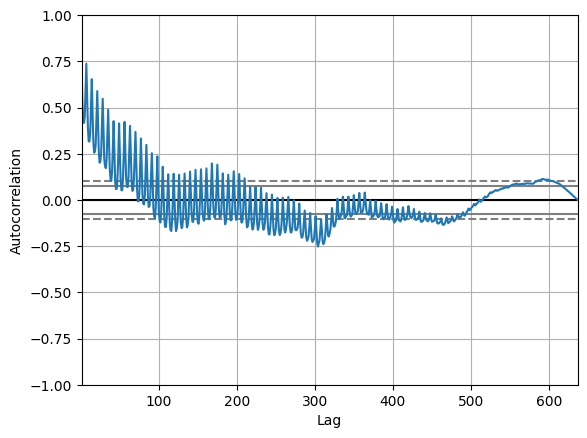

In [236]:
# Autocorrelation & Seasonality Check
df_claims['ClaimCreatedDT_UTC'] = pd.to_datetime(df_claims['ClaimCreatedDT_UTC'])
daily = df_claims_ts['2024-06-01':'2026-03-01'].resample('D').size()
autocorrelation_plot(daily)
plt.show()

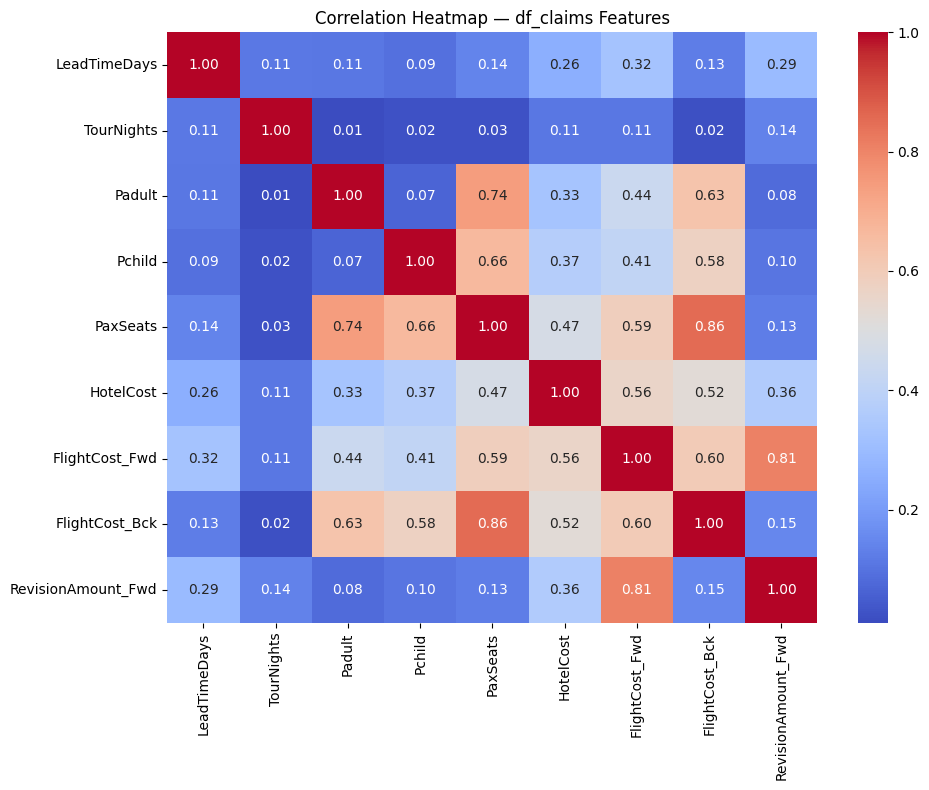

In [237]:
# Correlation heatmap claims
cols_claims = [
    'LeadTimeDays',
    'TourNights',
    'Padult',
    'Pchild',
    'PaxSeats',
    'HotelCost',
    'FlightCost_Fwd',
    'FlightCost_Bck',
    'RevisionAmount_Fwd'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df_claims[cols_claims].corr(method='spearman'), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — df_claims Features')
plt.tight_layout()
plt.show()

The claims dataset contains **37 674 rows** and **64 columns**, covering
the departure period from **January 2024 to March 2026**. Each row should represent a single tour package claim for the destination **Vietnam**, created by a travel agency on behalf of an end customer.

Pearson correlation analysis reveals several multicollinear features in df_claims. PaxSeats shows high correlation with Padult (0.74) and Pchild (0.66), making the individual passenger counts redundant. RevisionAmount_Fwd correlates strongly with FlightCost_Fwd (0.81). These pairs will be addressed during feature selection to avoid multicollinearity in the model.

The dataset includes the following key information:
- **Booking behaviour:** claim creation date, departure date, lead time
  in days, tour duration, number of nights
- **Passengers:** number of adults, children, and infants per booking
- **Product details:** hotel name, star rating, meal plan, room type,
  accommodation type, hotel region
- **Pricing:** hotel cost, flight cost (forward and return),
  total hotel cost, revision amounts
- **Flight information:** departure and arrival cities, flight class,
  airline partner, freight IDs

**Data Quality:**
- Missing values: 145
- Duplicate ClaimIDs: 0
- Duplicate rows: 0
- Currency: all USD
- No cancellations, this dataset contains only active bookings.

**Data Concerns:**
- 29 missing values in hotel-related fields all belong to the all belong to Dynamic Package and Beach Tours. Will be excluded from model training because the tour package should include hotel + flight.
- 27 zero lead time bookings claims created on the same day as departure. Will be excluded from model training.
- 9 Unpaid claims will be excluded from this model training.

# 3.2. Flights Data Overview

1. General Overview
2. Data Types
3. Duplicate Check
4. Basic Statistics
5. Airlines & Routes Distribution
6. Load Factor

In [238]:
# 1. General Overview
print(f'Rows: {df_flights.shape[0]:,}')
print(f'Columns: {df_flights.shape[1]}')
print(f'BlockDate: {df_flights["BlockDate"].min()} - {df_flights["BlockDate"].max()}')
print(f'Missing: {df_flights.isnull().sum().sum()}')

Rows: 4,015
Columns: 32
BlockDate: 2024-01-01 - 2026-03-05
Missing: 0


In [239]:
# 2. Data types
df_flights.dtypes

,0
snapshot_date,object
snapshot_ts_utc,object
FreightID,int64
FlightName,object
BlockDate,object
IsReturn,int64
AirlinePartnerID,int64
AirlineName,object
FlightClassID,int64
ClassAlias,object


In [240]:
# 3. Duplicate Check
print(f'Duplicate FreightIDs: {df_flights["FreightID"].duplicated().sum()}')
print(f'Duplicate rows:       {df_flights.duplicated().sum()}')

Duplicate FreightIDs: 3930
Duplicate rows:       0


In [241]:
# 4. Basic statistics
print(df_flights[['Seats_net', 'Sold_net', 'Empty',
                   'TotalDaysInSale']].describe().round(2))

       Seats_net  Sold_net    Empty  TotalDaysInSale
count    4015.00   4015.00  4015.00          4015.00
mean       61.17     48.20    12.97           156.71
std        40.19     41.68    31.44            60.05
min         1.00      0.00     0.00          -167.00
25%        30.00     20.00     0.00           115.00
50%        45.00     40.00     0.00           156.00
75%        87.00     64.00     3.00           202.00
max       348.00    344.00   183.00           297.00


In [242]:
#5. Airlines & Routes Distribution
print(df_flights['AirlineName'].value_counts())

AirlineName
SCAT ()                               1797
Air Astana ()                         1164
VietJet Air                            722
Qanot Sharq                            301
Selfie Travel (Селфи Тревел) ТОО        23
Pegas Kazakhstan (ПЕГАС КАЗАХСТАН)       3
Touroperator KOMPAS                      2
Selfie tour                              1
Crystal Bay Kazakhstan                   1
ANEX Tourism Worldwide DMCC              1
Name: count, dtype: int64


In [243]:
df_flights['Route'] = df_flights['CityFrom'] + ' -> ' + df_flights['CityTo']
print(df_flights['Route'].value_counts())

Route
Almaty -> Cam Ranh      582
Cam Ranh -> Almaty      564
Almaty -> Phu Quoc      453
Phu Quoc -> Almaty      452
Cam Ranh -> Astana      335
Astana -> Cam Ranh      335
Phu Quoc -> Astana      274
Astana -> Phu Quoc      273
Astana -> Da Nang        81
Da Nang -> Astana        80
Phu Quoc -> Tashkent     78
Tashkent -> Phu Quoc     77
Tashkent -> Cam Ranh     75
Cam Ranh -> Tashkent     74
Almaty -> Da Nang        74
Da Nang -> Almaty        72
Phu Quoc -> Shymkent     29
Shymkent -> Phu Quoc     28
Phu Quoc -> Aktobe       13
Phu Quoc -> Kostanay     13
Phu Quoc -> Ural`sk      13
Kostanay -> Phu Quoc     13
Aktobe -> Phu Quoc       13
Ural`sk -> Phu Quoc      13
Phuket -> Phu Quoc        1
Name: count, dtype: int64


In [244]:
print(df_flights['Country'].value_counts())

Country
Vietnam       2018
Kazakhstan    1845
Uzbekistan     152
Name: count, dtype: int64


In [245]:
# 6. Load Factor - the percentage of available seats that were sold on a flight. It is the target variable of this study
df_flights['LoadFactor'] = (df_flights['Sold_net'] / df_flights['Seats_net'] * 100).round(2)
print(df_flights['LoadFactor'].describe().round(2))

count    4015.00
mean       77.82
std        39.98
min         0.00
25%        93.33
50%       100.00
75%       100.00
max       100.00
Name: LoadFactor, dtype: float64


In [246]:
print(f'LF > 100% (sanity check): {(df_flights["LoadFactor"] > 100).sum()}')
print(f'LF = 100% (fully sold):  {(df_flights["LoadFactor"] == 100).sum()}')
print(f'LF = 0%   (empty):       {(df_flights["LoadFactor"] == 0).sum()}')
print(f'LF < 50%  (low demand):  {(df_flights["LoadFactor"] < 50).sum()}')
print(f'LF 50-80% (normal):      {((df_flights["LoadFactor"] >= 50) & (df_flights["LoadFactor"] < 80)).sum()}')
print(f'LF > 80%  (high demand): {(df_flights["LoadFactor"] >= 80).sum()}')

LF > 100% (sanity check): 0
LF = 100% (fully sold):  2665
LF = 0%   (empty):       488
LF < 50%  (low demand):  899
LF 50-80% (normal):      19
LF > 80%  (high demand): 3097


In [247]:
print(df_flights.groupby('AirlineName')['LoadFactor'].mean().round(2).sort_values(ascending=False))

AirlineName
Touroperator KOMPAS                   100.00
Air Astana ()                          99.03
SCAT ()                                77.73
Qanot Sharq                            73.64
VietJet Air                            47.80
Selfie Travel (Селфи Тревел) ТОО       26.09
ANEX Tourism Worldwide DMCC             0.00
Pegas Kazakhstan (ПЕГАС КАЗАХСТАН)      0.00
Crystal Bay Kazakhstan                  0.00
Selfie tour                             0.00
Name: LoadFactor, dtype: float64


In [248]:
# Check negative TotalDaysInSale
print(df_flights[df_flights['TotalDaysInSale'] < 0]['TotalDaysInSale'].describe())
print(f"\nCount: {(df_flights['TotalDaysInSale'] < 0).sum()}")

count      1.0
mean    -167.0
std        NaN
min     -167.0
25%     -167.0
50%     -167.0
75%     -167.0
max     -167.0
Name: TotalDaysInSale, dtype: float64

Count: 1


In [249]:
df_flights[df_flights['TotalDaysInSale'] < 0]

,snapshot_date,snapshot_ts_utc,FreightID,FlightName,BlockDate,IsReturn,AirlinePartnerID,AirlineName,FlightClassID,ClassAlias,...,Sold_gross,Empty,Seats_net,Sold_net,BlockRecords,TotalDaysInSale,ResourceCount,last_stamp,Route,LoadFactor
1248,2026-03-17,2026-03-17 16:54:53,13060,HH-2232,2024-03-08,1,195161,Qanot Sharq,2,Y,...,0,30,30,0,1,-167,1,38293143059,Cam Ranh -> Tashkent,0.0


In [250]:
print(df_flights['IsReturn'].value_counts())

IsReturn
0    2018
1    1997
Name: count, dtype: int64


The flight load history dataset contains **4 015 rows** and **32 columns**,
covering charter flight blocks operated on Kazakhstan -> Vietnam and Vietnam -> Kazakhstan routes, from **January 2024 to March 2026**.

Each row represents a single charter flight block assigned to the
operator, containing capacity and sales information at the time of
the data snapshot.

The dataset includes the following key information:
- **Flight details:** flight name, block date, airline partner,
  departure and arrival cities, flight class
- **Capacity:** gross seats available, net seats available
- **Demand signals:** seats sold (gross and net), empty seats,
  total days in sale
- **Operational flags:** hard block indicator, stop sale flag,
  on-request flag, release days

**Data Quality:**
- Missing values: **None detected**
- Duplicate rows: **0**
- Duplicate FreightIDs: **3,930** expected, as the same flight in different days

**Routes Distribution:**
- Main routes: Almaty - Cam Ranh, Almaty - Phu Quoc,
  Astana - Cam Ranh, Astana - Phu Quoc
- Countries covered: Vietnam, Kazakhstan, Uzbekistan

**TOP 3 Airlines:**
- SCAT
- Air Astana
- VietJet Air

**Data Concerns:**

- Seats_net / Sold_net used instead of gross_net values reflect only the Kazakhstan office allocation, which is the scope of this study.
- 152 Uzbekistan routes excluded, only Kazakhstan -> Vietnam direction is relevant for the model.
- LF = 0% (488 flights) flagged likely future flights or stopped sales, will be reviewed in EDA.
- LF = 100% (2,665 flights) the majority of flights are fully sold out, will be reviewed in EDA.
- 1 flight with TotalDaysInSale = -167 (Cam Ranh -> Tashkent), data error, excluded together with Uzbekistan routes.

TotalDaysInSale and days_to_first_reserve show perfect correlation (1.00), one will be excluded from the model to avoid multicollinearity. Flight-level features show weak correlation with LoadFactor (max 0.17), confirming that the main predictive signal will come from cumulative booking data reconstructed from claims.

**IMPORTANT!** No as-of (point-in-time) snapshots available, cumulative booking state at each window (D-90, D-60, D-30, D-7) will be reconstructed from claims data in the preprocessing step.

 # 4. Exploratory Data Analysis (EDA)

1. EDA for df_claims
2. EDA for df_flights

### 1) EDA for df_claims

1. Lead Time Distribution
2. Booking Pace Over Time
3. Seasonality Patterns
4. Price Distribution
5. PaxSeats
6. Top hotels / regions

#### 1. Lead Time Distribution

Lead time is the number of days between the booking creation
date and the departure date.

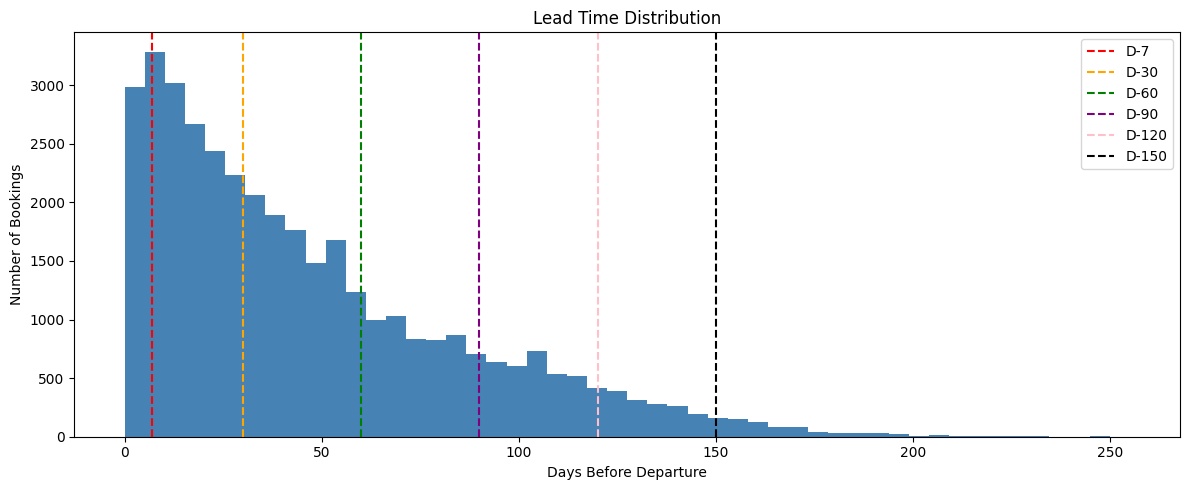

In [251]:
# Figure 1: Lead Time Distribution

# Step 1: Filter out LeadTimeDays = 0
claims_plt = df_claims['LeadTimeDays']

# Step 2: Create the histogram
plt.figure(figsize=(12, 5))
plt.hist(claims_plt, bins=50, color='steelblue')

# Step 3: Add vertical lines for each booking window
plt.axvline(x=7,  color='red',    linestyle='--', label='D-7')
plt.axvline(x=30, color='orange', linestyle='--', label='D-30')
plt.axvline(x=60, color='green',  linestyle='--', label='D-60')
plt.axvline(x=90, color='purple', linestyle='--', label='D-90')
plt.axvline(x=120, color='pink', linestyle='--', label='D-120')
plt.axvline(x=150, color='black', linestyle='--', label='D-150')

# Step 4: Add labels and title
plt.title('Lead Time Distribution')
plt.xlabel('Days Before Departure')
plt.ylabel('Number of Bookings')
plt.legend()
plt.tight_layout()
plt.show()

In [252]:
# % of bookings days before departure
for d in [7, 30, 60, 90, 120]:
    pct = (claims_plt >= d).sum() / len(claims_plt) * 100
    print(f"Booked by D-{d}: {pct:.1f}%")

Booked by D-7: 90.4%
Booked by D-30: 56.9%
Booked by D-60: 30.3%
Booked by D-90: 15.8%
Booked by D-120: 6.7%


#### 2. Booking Pace Over Time

Booking pace shows how many tour packages were booked per month.

In [253]:
# Convert to datetime
df_claims['ClaimCreatedDT_UTC'] = pd.to_datetime(df_claims['ClaimCreatedDT_UTC'])
df_claims['DepartureDT'] = pd.to_datetime(df_claims['DepartureDT'])

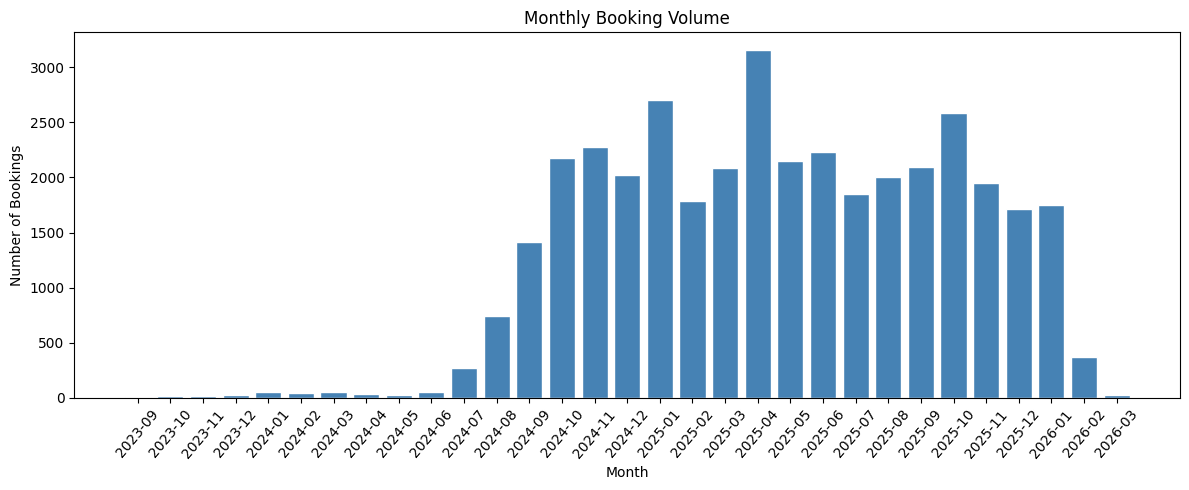

In [254]:
# Figure 2: Monthly Booking Volume

# Step 1: Extract the month from the booking date
df_claims['BookingMonth'] = df_claims['ClaimCreatedDT_UTC'].dt.to_period('M')

# Step 2: Count how many bookings happened in each month
monthly_active = df_claims.groupby('BookingMonth').size().reset_index(name='Bookings')

# Step 3: Draw the bar chart per month
plt.figure(figsize=(12, 5))
plt.bar(monthly_active['BookingMonth'].astype(str), monthly_active['Bookings'],
        color='steelblue', edgecolor='white')
plt.title('Monthly Booking Volume')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

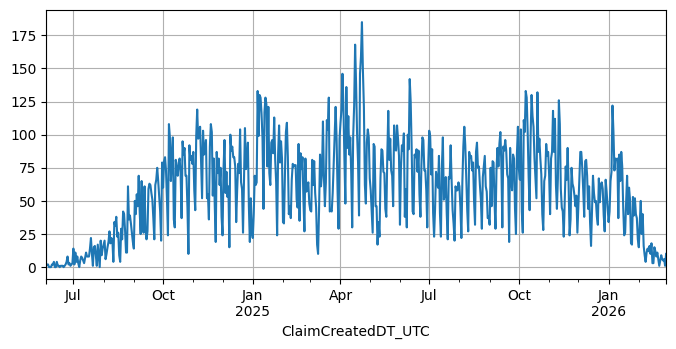

In [255]:
df_claims_ts = df_claims.set_index('ClaimCreatedDT_UTC').sort_index()

# Count bookings per day
daily = df_claims_ts['2024-06-01':'2026-03-01'].resample('D').size()
daily.plot(grid=True, figsize=(8, 3.5))
plt.show()

### 3. Seasonality Patterns

Seasonality analysis examines which months have the highest booking demand for Vietnam routes.

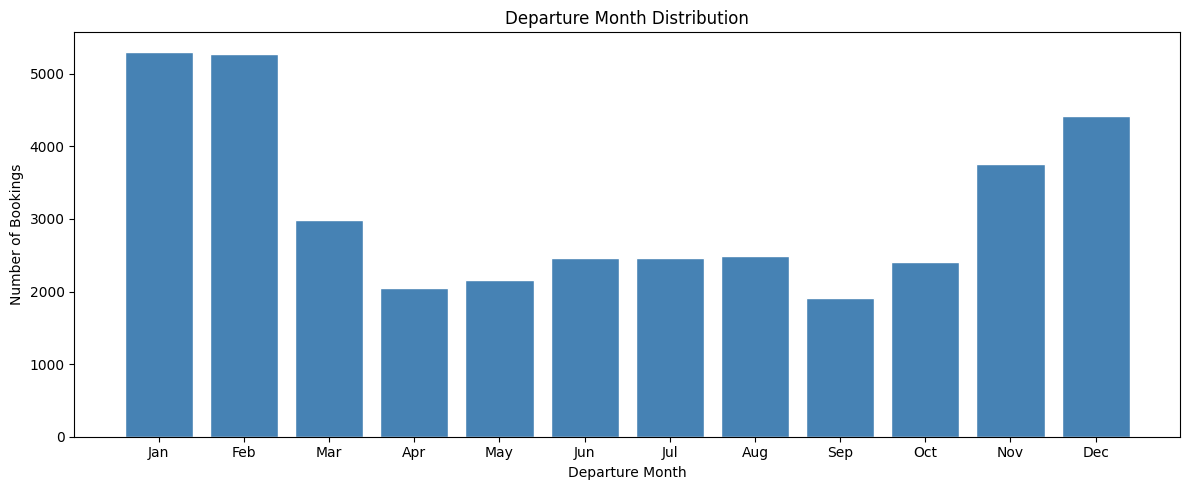

In [256]:
# Figure 3: Departure Month Distribution

# Step 1: Extract departure month
df_claims['DepartureMonth'] = df_claims['DepartureDT'].dt.month

# Step 2: Month names for readable format
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec']

# Step 3: Count how many bookings happened in each month
monthly_dep = df_claims.groupby('DepartureMonth').size()

# Step 4: Plot
plt.figure(figsize=(12, 5))
plt.bar(month_names, monthly_dep.values,
    color='steelblue', edgecolor='white')
plt.title('Departure Month Distribution')
plt.xlabel('Departure Month')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

### 4. Price Distribution

Price distribution analysis examines the spread of flight and hotel
costs across all bookings. This helps identify outliers, understand
pricing segments and prepare the Price Ratio feature for modelling.

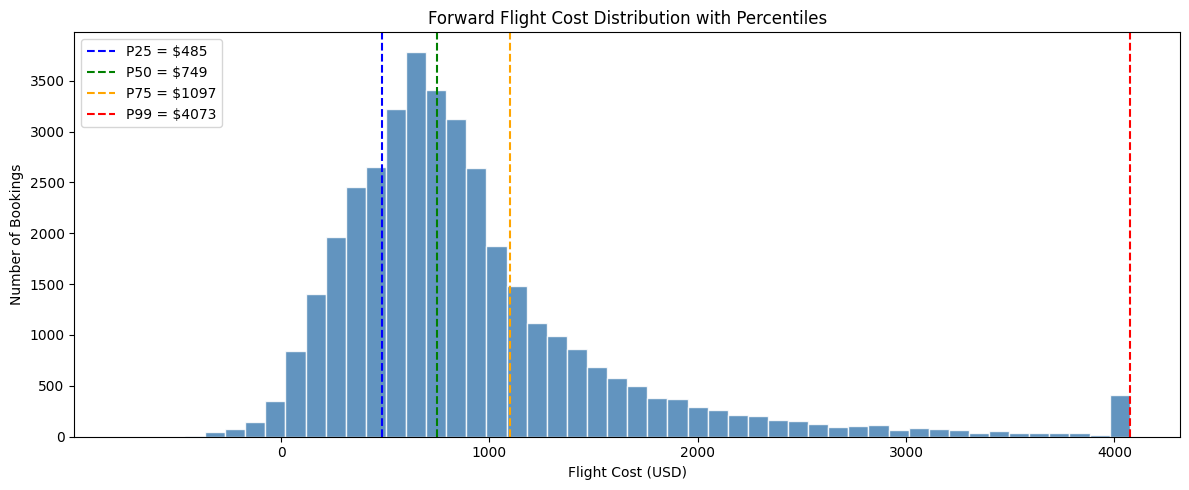

In [257]:
# Figure 4: Flight Cost Distribution

# Step 1: Calculate key percentiles
p25 = df_claims['FlightCost_Fwd'].quantile(0.25)
p50 = df_claims['FlightCost_Fwd'].quantile(0.50)
p75 = df_claims['FlightCost_Fwd'].quantile(0.75)
p99 = df_claims['FlightCost_Fwd'].quantile(0.99)

# Step 2: Plot histogram
plt.figure(figsize=(12, 5))
plt.hist(df_claims['FlightCost_Fwd'].clip(upper=p99),
        bins=50,
        color='steelblue',
        edgecolor='white',
        alpha=0.85)

# Step 3: Add vertical lines for each percentile
plt.axvline(x=p25, color='blue',   linestyle='--',
          linewidth=1.5, label=f'P25 = ${p25:.0f}')
plt.axvline(x=p50, color='green',  linestyle='--',
          linewidth=1.5, label=f'P50 = ${p50:.0f}')
plt.axvline(x=p75, color='orange', linestyle='--',
          linewidth=1.5, label=f'P75 = ${p75:.0f}')
plt.axvline(x=p99, color='red',    linestyle='--',
          linewidth=1.5, label=f'P99 = ${p99:.0f}')

# Step 4: Add labels and title
plt.title('Forward Flight Cost Distribution with Percentiles')
plt.xlabel('Flight Cost (USD)')
plt.ylabel('Number of Bookings')
plt.legend()
plt.tight_layout()
plt.show()


In [258]:
# Count anomalies
print(f'Negative flight costs: {(df_claims["FlightCost_Fwd"] < 0).sum()}')
print(f'Zero flight costs:     {(df_claims["FlightCost_Fwd"] == 0).sum()}')

Negative flight costs: 500
Zero flight costs:     3


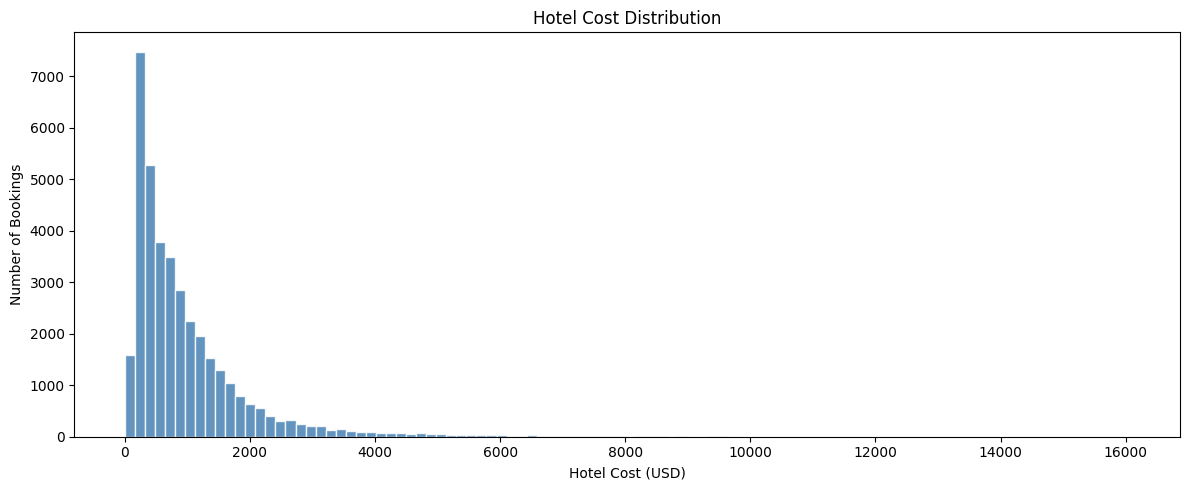

In [259]:
# Figure 4: Hotel Cost Distribution

# Step 1: Plot histogram with ALL hotel cost values
plt.figure(figsize=(12, 5))
plt.hist(df_claims['HotelCost'], bins=100,
    color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Hotel Cost Distribution')
plt.xlabel('Hotel Cost (USD)')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

In [260]:
# HotelCost statistics
print(df_claims['HotelCost'].describe().round(2))

count    37674.00
mean       991.23
std       1055.96
min          0.00
25%        329.46
50%        672.70
75%       1253.87
max      16063.42
Name: HotelCost, dtype: float64


In [261]:
# Zero and negative values
print('\nZero hotel cost:',
(df_claims['HotelCost'] == 0).sum())
print('Negative hotel cost:',
(df_claims['HotelCost'] < 0).sum())


Zero hotel cost: 14
Negative hotel cost: 0


### 5. PaxSeats
Passenger Group Size per Booking

In [262]:
print(df_claims['PaxSeats'].describe().round(2))

count    37674.00
mean         2.45
std          1.04
min          1.00
25%          2.00
50%          2.00
75%          3.00
max         11.00
Name: PaxSeats, dtype: float64


### 6. Top hotels / regions

In [263]:
# Top 10 hotels by booking volume
print(df_claims['HotelName'].value_counts().head(10))

HotelName
Wyndham Grand Phu Quoc                     2982
Wyndham Garden Grandworld Phu Quoc         1760
Queen Ann Nha Trang                        1627
Vinpearl Resort & Spa Phu Quoc             1264
Radisson Blu Resort Phu Quoc               1151
Premier Residences Phu Quoc Emerald Bay    1083
Sheraton Phu Quoc Long Beach Resort         974
Vinpearl Resort & Spa Nha Trang Bay         895
Aquamarine Resort Hotel Cam Ranh            764
Signature Hotel Nha Trang                   727
Name: count, dtype: int64


In [264]:
# Top regions
print(df_claims['HotelRegion'].value_counts())

HotelRegion
Phu Quoc      17789
Nha Trang     16553
Da Nang        2890
Hoyan           286
Phan Thiet      126
Khyue             1
Name: count, dtype: int64


# EDA for df_claims summary

1. **Lead Time Distribution**

Most bookings are made close to departure, only 15% of demand is visible at D-90. This confirms a late-booking market. However, for pricing decisions, the early window D-90 is most valuable to react and adjust prices effectively.

2. **Booking Pace Over Time**

Booking volume grew significantly from mid-2024 as this was a newly launched market. Therefore, model training will use data from 01.10.2024 to 28.02.2026 to capture real and stable demand patterns. From late 2025, monthly booking volume stabilised at around 1,700–2,000 bookings per month.

3. **Seasonality Patterns**

Peak departure months are January and February (5,300 bookings each), followed by December and November. The lowest demand is in September and April–May. This reflects a clear winter seasonality.

4. **Group Size Distribution**

PaxSeats median is 2, max is 11.

5. **Price Distribution**

Forward flight cost median is 749, with 25% paying over 1,097. Hotel cost median is 673, but the mean is 991 due to expensive outliers (max 16,063). 14 zero hotel cost bookings belong to Info Tours for agents and will be excluded.

6. **Top Hotels and Regions**

Phu Quoc (47%) and Nha Trang (44%) dominate demand. Da Nang represents only 8%. Wyndham Grand Phu Quoc is the most booked hotel with 2,982 bookings. HotelRegion will be an important feature for the model.

### 2) EDA for df_flights

1. Load Factor Distribution
2. Operational Flags
3. Sales Window Analysis
4. First reservation to departure
5. Flight Name Quality Check
6. Flight Cleaning
7. City Analysis
8. Flight Direction Analysis

###1. Load Factor Distribution
Load Factor is the percentage of available seats that were sold on a flight. It is the target variable of this study

/tmp/ipykernel_4219/1578286470.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


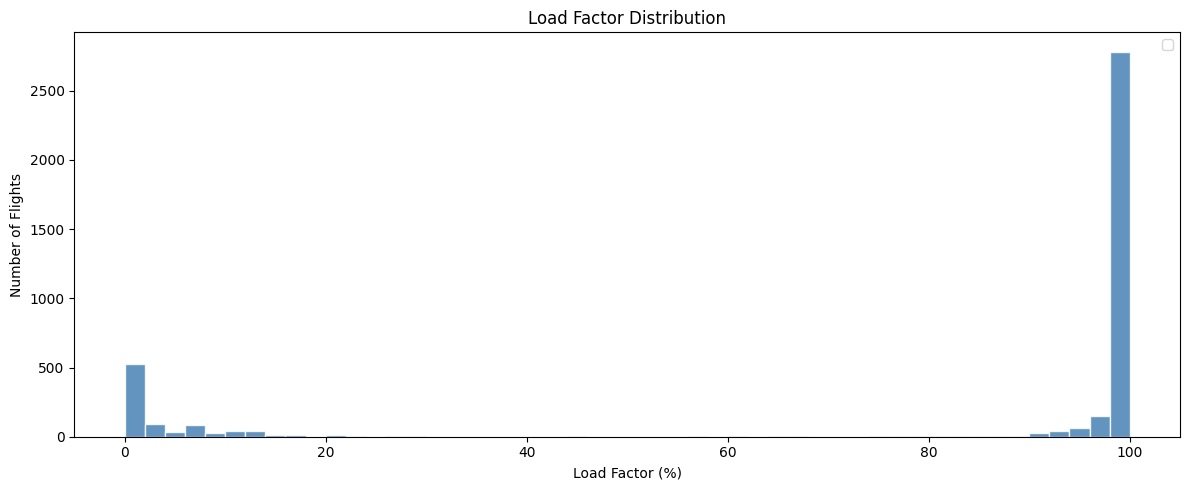

In [265]:
# Plot Load Factor distribution
plt.figure(figsize=(12, 5))
plt.hist(df_flights['LoadFactor'], bins=50,
         color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Load Factor Distribution')
plt.xlabel('Load Factor (%)')
plt.ylabel('Number of Flights')
plt.legend()
plt.tight_layout()
plt.show()

###2. Operational Flags

In [266]:
print(df_flights['HasStopSale'].value_counts())
print('-------------------')
print(df_flights['IsOnRequest'].value_counts())
print('-------------------')
print(df_flights['hard_block'].value_counts())
print('-------------------')
print(df_flights['ClassAlias'].value_counts())

HasStopSale
0    3512
1     503
Name: count, dtype: int64
-------------------
IsOnRequest
0    4015
Name: count, dtype: int64
-------------------
hard_block
1    4015
Name: count, dtype: int64
-------------------
ClassAlias
Y    4015
Name: count, dtype: int64


### 3. Sales Window Analysis

In [267]:
print(df_flights['TotalDaysInSale'].describe().round(1))

count    4015.0
mean      156.7
std        60.1
min      -167.0
25%       115.0
50%       156.0
75%       202.0
max       297.0
Name: TotalDaysInSale, dtype: float64


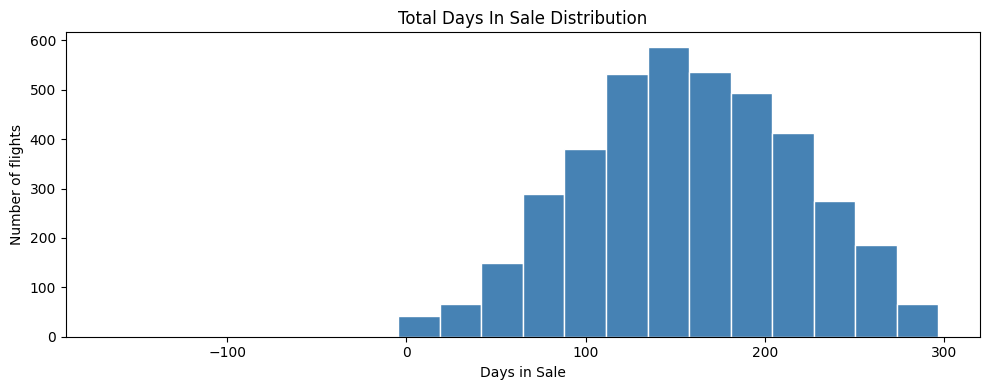

In [268]:
fig, ax = plt.subplots(figsize=(10, 4))
df_flights['TotalDaysInSale'].dropna().plot(kind='hist', bins=20, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Total Days In Sale Distribution')
ax.set_xlabel('Days in Sale')
ax.set_ylabel('Number of flights')
plt.tight_layout()
plt.show()

### 4. First reservation to departure

In [269]:
# days from first reservation to departure
df_flights['first_reserve_utc'] = pd.to_datetime(df_flights['first_reserve_utc'])
df_flights['BlockDate'] = pd.to_datetime(df_flights['BlockDate'])

df_flights['days_to_first_reserve'] = (df_flights['BlockDate'] - df_flights['first_reserve_utc']).dt.days
print(df_flights['days_to_first_reserve'].describe().round(1))

count    4015.0
mean      155.7
std        60.1
min      -168.0
25%       114.0
50%       155.0
75%       201.0
max       296.0
Name: days_to_first_reserve, dtype: float64


### 5. Flight Name Quality Check

In [270]:
print(df_flights['FlightName'].unique())

['VSV5208' 'VJ61' 'VSV5319' 'VSV5333.' 'VSV5331..' 'VJ67' 'VSV5355'
 'VSV5251' 'VSV5335.' 'VSV5321.' 'VSV5253.' 'VSV5251.' 'VSV5207' 'VSV5318'
 'VSV5320.' 'VJ62' 'VSV5330..' 'VSV5332.' 'VSV5334.' 'VJ68' 'VSV5250...'
 'VSV5354' 'VSV5331.' 'KC162' 'VSV5339' 'VSV5321' 'VSV5317'
 'VSV5330íåàêò(ñìåíàðåéñîâ)' 'KC174' 'HH2234' 'KC161' 'VSV5320' 'VSV5338'
 'KC173' 'VSV5316' 'HH2233' 'VSV5331íåàêò(ñìåíàðåéñà)' 'KC158' 'KC194'
 'VSV5343' 'VJ61.' 'VSV5341' 'KC193' 'KC157' 'VSV5340' 'VSV5342' 'VSV5312'
 'VSV5308' 'VSV5331' 'VSV5302' 'VSV5337' 'VSV5313' 'VSV5330' 'VSV5309'
 'VSV5303' 'VSV5336' 'HH-2232' 'HH-2231' 'VSV5351' 'VSV5350' 'VJ67.'
 'VSV5339..' 'Test' 'VSV4444test' 'VSV5341.' 'KC260' 'HH-2238' 'VSV5340.'
 'HH-2237' 'KC259' 'VSV5208.' 'HH-2231.' 'KC600' 'KC599' 'VSV5351.'
 'VJ68.' 'VSV5315' 'VSV10000TEST' 'VSV5314' 'VSV9999TEST' 'VSV5354.'
 'VSV5319.' 'VZ8934' 'HH-2235' 'KC162.']


In [271]:
long_names = df_flights[df_flights['FlightName'].str.len() > 10]['FlightName'].unique()
print(long_names)

['VSV5330íåàêò(ñìåíàðåéñîâ)' 'VSV5331íåàêò(ñìåíàðåéñà)' 'VSV4444test'
 'VSV10000TEST' 'VSV9999TEST']


In [272]:
test_flights = df_flights[df_flights['FlightName'].str.lower().str.contains('test|fake', na=False)]['FlightName'].unique()
print(test_flights)

['Test' 'VSV4444test' 'VSV10000TEST' 'VSV9999TEST']


###6. Flight Cleaning

In [273]:
exclude_pattern = r'test|fake|íåàêò'

In [274]:
df_clean = df_flights[
    ~df_flights['FlightName'].str.contains(exclude_pattern, case=False, na=False) &
    (df_flights['TotalDaysInSale'] > 0) &
    (df_flights['CityFrom'] != 'Tashkent')
].copy()

In [275]:
# FreightID + BlockDate = unique flight on a specific date
print(f'Unique FreightIDs: {df_clean["FreightID"].nunique()}')
print(f'Unique FreightID + BlockDate: {df_clean.groupby(["FreightID", "BlockDate"]).ngroups}')

Unique FreightIDs: 74
Unique FreightID + BlockDate: 3818


In [276]:
print('-------- FreightID + BlockDate -----------')
print(f'Before:    {df_flights.groupby(["FreightID", "BlockDate"]).ngroups} flights')
print(f'After:    {df_clean.groupby(["FreightID", "BlockDate"]).ngroups} flights')

print('-------- FreightID -----------')
print(f'Before: {df_flights.FreightID.nunique()} flights')
print(f'After: {df_clean.FreightID.nunique()} flights')

-------- FreightID + BlockDate -----------
Before:    4007 flights
After:    3818 flights
-------- FreightID -----------
Before: 85 flights
After: 74 flights


### 7. City Analysis

In [277]:
print(df_clean[['CityFrom', 'Country', 'BusinessEntity']].drop_duplicates().sort_values('CityFrom'))

      CityFrom     Country BusinessEntity
677     Aktobe     Vietnam             KZ
58      Almaty     Vietnam             KZ
63      Astana     Vietnam             KZ
0     Cam Ranh  Kazakhstan             KZ
809   Cam Ranh  Uzbekistan             KZ
417    Da Nang  Kazakhstan             KZ
688   Kostanay     Vietnam             KZ
2     Phu Quoc  Kazakhstan             KZ
297   Phu Quoc  Uzbekistan             KZ
2881    Phuket     Vietnam             KZ
681   Shymkent     Vietnam             KZ
693    Ural`sk     Vietnam             KZ


In [278]:
print(df_clean.groupby('CityFrom')['FreightID'].nunique().sort_values(ascending=False))

df_last_clean = (
    df_clean
    .sort_values('snapshot_ts_utc')
    .groupby('FreightID', as_index=False)
    .last()
)

CityFrom
Phu Quoc    24
Almaty      16
Cam Ranh    13
Astana      11
Da Nang      5
Aktobe       1
Kostanay     1
Phuket       1
Shymkent     1
Ural`sk      1
Name: FreightID, dtype: int64


### 8. Flight Direction Analysis

In [279]:
KZ_CITIES = ['Almaty', 'Astana', 'Shymkent', 'Kostanay', 'Aktobe', 'Ural`sk',
             'Karaganda', 'Pavlodar', 'Semey', 'Oskemen', 'Atyrau', 'Aktau',
             'Kyzylorda', 'Taraz', 'Petropavl', 'Rudny']

In [280]:
# KZ -> Vietnam
fwd = df_clean[
    (df_clean['IsReturn'] == 0) &
    (df_clean['CityFrom'].isin(KZ_CITIES))
][['FreightID', 'BlockDate', 'CityFrom', 'CityTo']].drop_duplicates()

# Vietnam -> KZ
bck = df_clean[
    (df_clean['IsReturn'] == 1) &
    (df_clean['CityTo'].isin(KZ_CITIES))
][['FreightID', 'BlockDate', 'CityFrom', 'CityTo']].drop_duplicates()

print(f'Flights Forward: {fwd.FreightID.nunique()}')
print(f'Flights Back: {bck.FreightID.nunique()}')
print(f'BlockDate Forward Range: {fwd.BlockDate.min()} - {fwd.BlockDate.max()}')
print(f'BlockDate Back Range: {bck.BlockDate.min()} - {bck.BlockDate.max()}')


Flights Forward: 31
Flights Back: 39
BlockDate Forward Range: 2024-01-01 00:00:00 - 2026-03-05 00:00:00
BlockDate Back Range: 2024-01-01 00:00:00 - 2026-03-05 00:00:00


In [328]:
# Grain Forward (FreightID × BlockDate)
grain_fwd = df_clean[
    (df_clean['IsReturn'] == 0) &
    (df_clean['CityFrom'].isin(KZ_CITIES))
][['FreightID', 'BlockDate', 'FlightName',
   'CityFrom', 'CityTo', 'AirlineName',
   'Seats_gross', 'Sold_gross',
   'Seats_net', 'Sold_net', 'LoadFactor',
   'HasStopSale', 'TotalDaysInSale',
   'days_to_first_reserve', 'releasedays',
   'first_reserve_utc']].drop_duplicates()

print(f'Unique FreightID × BlockDate (FRW): {len(grain_fwd)}')
print(f'Unique FreightID (FRW): {grain_fwd.FreightID.nunique()}')
print(grain_fwd.groupby(['FreightID','FlightName'])['BlockDate'].count().sort_values(ascending=False).head(10))

Unique FreightID × BlockDate (FRW): 1835
Unique FreightID (FRW): 31
FreightID  FlightName
10669      VSV5207       218
13586      KC161         218
11537      VJ62          194
10934      VJ68          169
14230      KC193         123
14072      KC173         103
12848      VSV5354       102
12522      VSV5318        89
13078      VSV5350        88
13507      VSV5320        81
Name: BlockDate, dtype: int64


In [282]:
check = grain_fwd.groupby(['FreightID', 'BlockDate'])['AirlineName'].nunique()
print(f'Max Airline for FreightID × BlockDate: {check.max()}')
print(f'Cases > 1: {(check > 1).sum()}')

Max Airline for FreightID × BlockDate: 1
Cases > 1: 0


In [329]:
# Grain Back (FreightID × BlockDate)
grain_bck = df_clean[
    (df_clean['IsReturn'] == 1) &
    (df_clean['CityTo'].isin(KZ_CITIES))
][['FreightID', 'BlockDate', 'FlightName',
   'CityFrom', 'CityTo', 'AirlineName',
   'Seats_gross', 'Sold_gross',
   'Seats_net', 'Sold_net', 'LoadFactor',
   'HasStopSale', 'TotalDaysInSale',
   'days_to_first_reserve', 'releasedays',
   'first_reserve_utc']].drop_duplicates()


print(f'Unique FreightID × BlockDate (BACK): {len(grain_bck)}')
print(f'Unique FreightID (BACK): {grain_bck.FreightID.nunique()}')
print(grain_bck.groupby(['FreightID','FlightName'])['BlockDate'].count().sort_values(ascending=False).head(10))

Unique FreightID × BlockDate (BACK): 1831
Unique FreightID (BACK): 39
FreightID  FlightName
10670      VSV5208       218
13587      KC162         212
11538      VJ61          190
10935      VJ67          168
14231      KC194         123
14073      KC174         101
12849      VSV5355       100
13079      VSV5351        90
12523      VSV5319        89
13508      VSV5321        82
Name: BlockDate, dtype: int64


In [330]:
check = grain_bck.groupby(['FreightID', 'BlockDate'])['AirlineName'].nunique()
print(f'Max Airline for FreightID × BlockDate: {check.max()}')
print(f'Cases > 1: {(check > 1).sum()}')

Max Airline for FreightID × BlockDate: 1
Cases > 1: 0


In [331]:
print('=== Forward ===')
print(grain_fwd['LoadFactor'].describe().round(3))
print(f'\n=== Back ===')
print(grain_bck['LoadFactor'].describe().round(3))

=== Forward ===
count    1835.000
mean       79.173
std        39.024
min         0.000
25%        95.000
50%       100.000
75%       100.000
max       100.000
Name: LoadFactor, dtype: float64

=== Back ===
count    1831.000
mean       77.926
std        39.826
min         0.000
25%        93.330
50%       100.000
75%       100.000
max       100.000
Name: LoadFactor, dtype: float64


# EDA summary: df_flights

**1. Load Factor Distribution**

The target variable LoadFactor shows a bimodal distribution with peaks at 0% and 100%, confirming that the dataset represents final flight states rather than in-progress booking states. Flights with LF=0% (future or unsold flights) will be excluded from model training. The remaining distribution is left-skewed, with the majority of flights fully sold.Cumulative booking state will be reconstructed from claims data in the preprocessing step.

**2. Operational Flags**

HasStopSale: 503 flights (12.5%) have stop sale activated. Will be used as a feature.
IsOnRequest, hard_block, ClassAlias: no variation and will be excluded from model.

**3. Sales Window Analysis**

Flights are on sale for a median of 156 days (roughly 5 months). Distribution is approximately normal between 100–250 days. TotalDaysInSale will be considered as a feature.

**4. First Reservation to Departure**

Flights open for sale a median 155 days before departure.

**5. Flight Name Quality Check**

test flights were detected (Test, VSV4444test, VSV10000TEST, VSV9999TEST) and flights with corrupted names containing Cyrillic encoding errors — all excluded from analysis.

**6. Flight Cleaning**

After removing test flights, Tashkent routes and negative TotalDaysInSale: 74 unique FreightIDs, 3,818 unique FreightID × BlockDate combinations remain.

**7. City Analysis**

All flights belong to KZ business entity. Main departure cities: Phu Quoc (24), Almaty (16), Cam Ranh (13), Astana (11). Uzbekistan routes excluded.

**8. Flight Direction Analysis**

Forward (KZ -> VN): 31 unique flights, 1,835 departure dates
Return (VN -> KZ): 39 unique flights, 1,831 departure dates
Each FreightID × BlockDate has exactly 1 airline, no conflicts detected

# 5. Data Preprocessing

In [332]:
df_claims_clean = df_claims[
    (df_claims['LeadTimeDays'] > 0) &
    (df_claims['HotelName'].notna()) &
    (df_claims['StatusName'].isin(['Paid', 'Confirmed'])) &
    (df_claims['DepartureDT'] >= '2024-10-01') &
    (df_claims['DepartureDT'] <= '2026-02-28')
].copy()

print(f"Final clean claims: {len(df_claims_clean):,}")
print(f"Booking dates range: {df_claims_clean['ClaimCreatedDT_UTC'].min().date()} — {df_claims_clean['ClaimCreatedDT_UTC'].max().date()}")
print(f"Departure dates range: {df_claims_clean['DepartureDT'].min().date()} — {df_claims_clean['DepartureDT'].max().date()}")

Final clean claims: 36,863
Booking dates range: 2024-03-18 — 2026-02-27
Departure dates range: 2024-10-01 — 2026-02-28


In [333]:
df_claims_clean = df_claims_clean[
    df_claims_clean['FreightID_Fwd'].isin(grain_fwd_clean['FreightID'])
].copy()

print(f"Claims after route filter: {len(df_claims_clean):,}")
print(f"Unique FreightIDs: {df_claims_clean['FreightID_Fwd'].nunique()}")

Claims after route filter: 35,382
Unique FreightIDs: 26


In [334]:
# Filter grain_fwd and grain_bck to match training period
grain_fwd_clean = grain_fwd[
    (grain_fwd['BlockDate'] >= '2024-10-01') &
    (grain_fwd['BlockDate'] <= '2026-02-28')
].copy()

grain_bck_clean = grain_bck[
    (grain_bck['BlockDate'] >= '2024-10-01') &
    (grain_bck['BlockDate'] <= '2026-02-28')
].copy()

print(f"grain_fwd: {len(grain_fwd):,} {len(grain_fwd_clean):,}")
print(f"grain_bck: {len(grain_bck):,} {len(grain_bck_clean):,}")
print(f"Period fwd: {grain_fwd_clean['BlockDate'].min().date()} — {grain_fwd_clean['BlockDate'].max().date()}")
print(f"Period bck: {grain_bck_clean['BlockDate'].min().date()} — {grain_bck_clean['BlockDate'].max().date()}")

grain_fwd: 1,835 1,432
grain_bck: 1,831 1,422
Period fwd: 2024-10-01 — 2026-02-28
Period bck: 2024-10-01 — 2026-02-28


**Cleaned during EDA:**
1. Removed 4 test flights (VSV9999TEST, VSV4444test, etc.)
2. Removed 152 Uzbekistan routes (CityFrom = Tashkent)

Additionally:
- Created df_clean grain_fwd (KZ->VN) and grain_bck (VN->KZ)
- LF=0% (201 fwd / 205 bck): retained, will be excluded before model training
- LF=100% (1 197 flights \ 65%): retained, acknowledged as a demand censoring limitation


**Cleaned during Preprocessing step:**

--df_claims_clean--
1. Removed 27 zero lead time bookings (created on departure day)
2. Removed 29 Dynamic Package bookings (no hotel = out of scope)
3. Removed 9 unpaid claims (incomplete transactions)
4. Removed 2,733 records before Oct 2024 (startup noise)
5. Removed 20 records after Feb 2026 (incomplete period)
6. Retained 16 zero-price Beach Tours (valid paid, flagged in Feature Engineering)
7. Retained 484 negative FlightCost_Fwd (valid price revisions)
8. Claims filtered by route (removed 1,428 non-Vietnam)
**Result:** 37,674 -> 36,863 records (97.8% retention)

--grain_fwd and grain_bck--
1. grain_fwd filtered: 1,835 -> 1,432 flights (Oct 2024 – Feb 2026)
2. grain_bck filtered: 1,831 -> 1,422 flights (Oct 2024 – Feb 2026)



# 6. Joint Analysis and Booking Curve Reconstruction

## Joint Analysis (df_claims_clean + grain_fwd_clean -> df_joined_all)

In [336]:
# STEP 1: Exact join (DepartureDT = BlockDate)
df_exact = df_claims_clean.merge(
    grain_fwd_clean,
    left_on=['FreightID_Fwd', 'DepartureDT'],
    right_on=['FreightID', 'BlockDate'],
    how='inner'
)
df_exact['date_match'] = 'exact'
print(f"Exact match: {len(df_exact):,}")

Exact match: 34,103


In [337]:
# STEP 2: +1 day join for remaining unmatched claims
remaining = df_claims_clean[
    ~df_claims_clean['ClaimID'].isin(df_exact['ClaimID'])
].copy()
remaining['DepartureDT_plus1'] = remaining['DepartureDT'] + pd.Timedelta(days=1)

df_plus1 = remaining.merge(
    grain_fwd_clean,
    left_on=['FreightID_Fwd', 'DepartureDT_plus1'],
    right_on=['FreightID', 'BlockDate'],
    how='inner'
)
df_plus1['date_match'] = 'plus1_day'
print(f"+1 day match: {len(df_plus1):,}")

+1 day match: 928


In [338]:
# STEP 3: -1 day join for still unmatched claims
remaining2 = df_claims_clean[
    ~df_claims_clean['ClaimID'].isin(df_exact['ClaimID']) &
    ~df_claims_clean['ClaimID'].isin(df_plus1['ClaimID'])
].copy()
remaining2['DepartureDT_minus1'] = remaining2['DepartureDT'] - pd.Timedelta(days=1)

df_minus1 = remaining2.merge(
    grain_fwd_clean,
    left_on=['FreightID_Fwd', 'DepartureDT_minus1'],
    right_on=['FreightID', 'BlockDate'],
    how='inner'
)
df_minus1['date_match'] = 'minus1_day'
print(f"-1 day match: {len(df_minus1):,}")

-1 day match: 338


In [339]:
# STEP 4: Combine all three results
df_joined_all = pd.concat(
    [df_exact, df_plus1, df_minus1],
    ignore_index=True
)

print(f"\nFinal Result")
print(f"Total joined:   {len(df_joined_all):,} ({len(df_joined_all)/len(df_claims_clean)*100:.1f}%)")
print(f"Unique flights: {df_joined_all.groupby(['FreightID','BlockDate']).ngroups:,}")
print(f"Unjoined:       {len(df_claims_clean) - len(df_joined_all):,}")


Final Result
Total joined:   35,369 (100.0%)
Unique flights: 1,420
Unjoined:       13


In [340]:
# df_joined_all — Sanity Check

print(df_joined_all.shape)
print(df_joined_all.columns.tolist())

(35369, 85)
['snapshot_date', 'snapshot_ts_utc', 'ClaimID', 'TourID', 'StatusID', 'StatusName', 'IsCancelled', 'ClaimCreatedDT_UTC', 'raw_event_time_utc', 'DepartureDT', 'TourEndDT', 'ConfirmedDT_UTC', 'LeadTimeDays', 'TourNights', 'TourNightsCalc', 'HotelNights', 'StateID', 'CountryName', 'TourTypeID', 'TourTypeName', 'Padult', 'Pchild', 'Pinfant', 'PaxSeats', 'PaxHotel', 'HotelID', 'HotelName', 'StarID', 'HotelStars', 'MealID', 'MealName', 'RoomTypeID', 'RoomTypeName', 'AccommodationID', 'AccommodationName', 'HotelRegionID', 'HotelRegion', 'HotelCost', 'HotelCount', 'TotalHotelCost', 'FreightID_Fwd', 'FreightID_Bck', 'DepartureCityID', 'DepartureCityName', 'ArrivalCityID', 'ArrivalCityName', 'ReturnDepartureCityID', 'ReturnDepartureCityName', 'ReturnArrivalCityID', 'ReturnArrivalCityName', 'FlightClassID_Fwd', 'FlightClass_Fwd', 'FlightClassID_Bck', 'FlightClass_Bck', 'FlightPartnerID_Fwd', 'FlightPartner_Fwd', 'FlightPartnerID_Bck', 'FlightPartner_Bck', 'FlightCost_Fwd', 'FlightCost

In [341]:
# Remove helper columns

df_joined_all = df_joined_all.drop(
    columns=['DepartureDT_plus1', 'DepartureDT_minus1', 'FreightID']
)

print(f"Shape after cleanup: {df_joined_all.shape}")
print(f"Columns: {len(df_joined_all.columns)}")

Shape after cleanup: (35369, 82)
Columns: 82


#Join Analysis Summary


Goal: Link each booking (claim) to its specific flight block
Join key: FreightID_Fwd (claim) = FreightID (flight) + DepartureDT = BlockDate

**Challenges and Solutions**

*Timezone date shift:* DepartureDT in claims and BlockDate in flights occasionally differ by ±1 day due to UTC timezone conversion (Kazakhstan is UTC+5)

Solution: applied a three-step join with date tolerance:

Step 1 exact match:  34, 103 claims

Step 2 +1 day shift:    928 claims recovered

Step 3 -1 day shift:    338 claims recovered

**Output**
- df_joined_all: 35,369 claims linked to flights (100% recovery rate)
- Unique flights covered: 1,420
- Unjoined:*italicised text* 13 unexplained (< 0.1%)

## Booking Curve Reconstruction

**Goal:** For each flight, calculate how many seats were booked at each booking window: D-90, D-60, D-30, D-7 days before departure.

**Logic:** If a flight departs on 2025-04-01:

D-90 = 2025-04-01 - 90 days = 2024-12-31

D-60 = 2025-04-01 - 60 days = 2025-01-30

D-30 = 2025-04-01 - 30 days = 2025-03-02

D-7  = 2025-04-01 - 7 days  = 2025-03-25

A booking IS visible at window D-X if: ClaimCreatedDT_UTC <= BlockDate - X days.

We multiply the flag (0 or 1) by PaxSeats to get the number of seats booked at each window

In [352]:
# Step 1: For each booking, create a flag per window
# 1 = booking was already made by this window
# 0 = booking was made AFTER this window (not visible yet)

windows = {'D90': 90, 'D60': 60, 'D30': 30, 'D7': 7}

for window_name, days in windows.items():
    cutoff = df_joined_all['BlockDate'] - pd.Timedelta(days=days)
    is_visible = df_joined_all['ClaimCreatedDT_UTC'] <= cutoff
    df_joined_all[f'seats_{window_name}'] = (
        is_visible.astype(int) * df_joined_all['PaxSeats']
    )

In [353]:
# Step 2: Aggregate per flight
# Sum up all seats per flight at each window

df_curves = df_joined_all.groupby(
    ['FreightID_Fwd', 'BlockDate']
).agg(
    # How many seats were booked by each window
    cum_seats_D90  = ('seats_D90',   'sum'),
    cum_seats_D60  = ('seats_D60',   'sum'),
    cum_seats_D30  = ('seats_D30',   'sum'),
    cum_seats_D7   = ('seats_D7',    'sum'),

    # Flight capacity
    Seats_gross    = ('Seats_gross', 'first'),
    Sold_gross     = ('Sold_gross',  'first'),
    LoadFactor     = ('LoadFactor',  'first'),
    AirlineName    = ('AirlineName', 'first'),
    CityFrom       = ('CityFrom',    'first'),
    CityTo         = ('CityTo',      'first'),
    HasStopSale    = ('HasStopSale', 'first'),

    # Hotel signals
    unique_hotels  = ('HotelName',   'nunique'),
    avg_hotel_cost = ('HotelCost',   'mean'),
    total_bookings = ('ClaimID',     'count')
).reset_index()

In [355]:
print(f"Before: {len(df_joined_all):,} rows (one per booking)")
print(f"After:  {len(df_curves):,} rows (one per flight)")

Before: 35,369 rows (one per booking)
After:  1,420 rows (one per flight)


In [359]:
# Step 3: Calculate Loaf Factor per Window
# LF at window = seats booked by that point / total gross capacity

for window in ['D90', 'D60', 'D30', 'D7']:
    df_curves[f'LF_{window}'] = (
        df_curves[f'cum_seats_{window}'] /
        df_curves['Seats_gross'] * 100
    ).clip(upper=100).round(1)

In [362]:
# Step 4: SANITY CHECK
not_monotonic = df_curves[
    (df_curves['cum_seats_D90'] > df_curves['cum_seats_D60']) |
    (df_curves['cum_seats_D60'] > df_curves['cum_seats_D30']) |
    (df_curves['cum_seats_D30'] > df_curves['cum_seats_D7'])
]

print(f"Flights reconstructed:  {len(df_curves):,}")
print(f"Non-monotonic curves:   {len(not_monotonic):,}")
print(f"\nLoad Factor Progression")
print(df_curves[['LF_D90','LF_D60','LF_D30','LF_D7','LoadFactor']].mean().round(1))

Flights reconstructed:  1,420
Non-monotonic curves:   0

Load Factor Progression
LF_D90        15.3
LF_D60        29.9
LF_D30        54.8
LF_D7         82.3
LoadFactor    99.1
dtype: float64


#Booking Curve Reconstruction Summary


For each flight was reconstructed cumulative booking statesat four booking windows using ClaimCreatedDT_UTC as timestamp

**Results:**

- LF_D90 mean = 15.3% - only 15% of demand visible at D-90

- LF_D60 mean = 29.9%

- LF_D30 mean = 54.8%

- LF_D7  mean = 82.3%

-  Final LF    = 99.1%

This confirms the exponential booking curve pattern documented across perishable asset industries (Shintani & Umeno, 2023)

Over-capacity values (LF > 100%) are capped at 100%

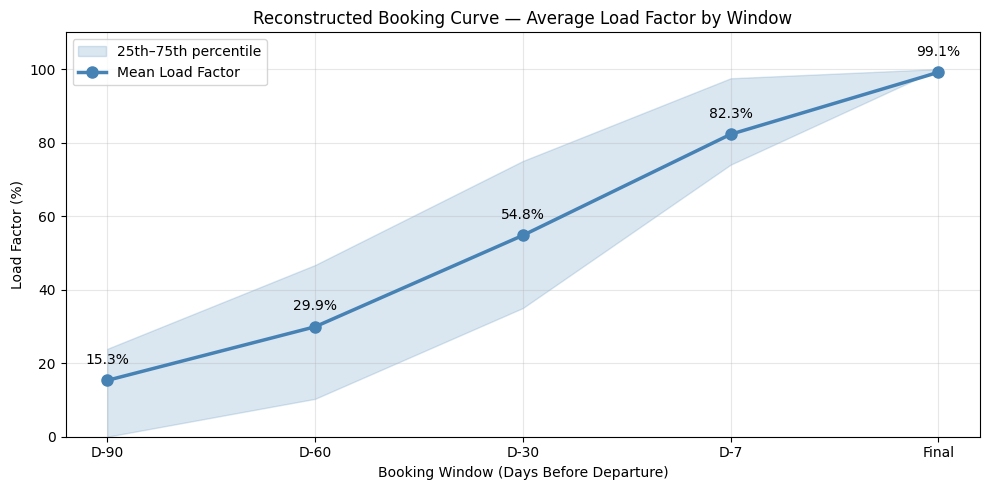

In [363]:
# Booking Curve Visualization

# Calculate mean LF at each window across all flights
windows_labels = ['D-90', 'D-60', 'D-30', 'D-7', 'Final']
mean_lf = [
    df_curves['LF_D90'].mean(),
    df_curves['LF_D60'].mean(),
    df_curves['LF_D30'].mean(),
    df_curves['LF_D7'].mean(),
    df_curves['LoadFactor'].mean()
]

# Also show 25th and 75th percentile as shaded area
p25 = [
    df_curves['LF_D90'].quantile(0.25),
    df_curves['LF_D60'].quantile(0.25),
    df_curves['LF_D30'].quantile(0.25),
    df_curves['LF_D7'].quantile(0.25),
    df_curves['LoadFactor'].quantile(0.25)
]

p75 = [
    df_curves['LF_D90'].quantile(0.75),
    df_curves['LF_D60'].quantile(0.75),
    df_curves['LF_D30'].quantile(0.75),
    df_curves['LF_D7'].quantile(0.75),
    df_curves['LoadFactor'].quantile(0.75)
]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

# Shaded area = 25th to 75th percentile
ax.fill_between(windows_labels, p25, p75,
                alpha=0.2, color='steelblue',
                label='25th-75th percentile')

# Mean line
ax.plot(windows_labels, mean_lf,
        color='steelblue', linewidth=2.5,
        marker='o', markersize=8,
        label='Mean Load Factor')

# Add value labels
for i, (label, val) in enumerate(zip(windows_labels, mean_lf)):
    ax.annotate(f'{val:.1f}%',
                xy=(i, val),
                xytext=(0, 12),
                textcoords='offset points',
                ha='center', fontsize=10)

ax.set_title('Reconstructed Booking Curve - Average Load Factor by Window')
ax.set_xlabel('Booking Window (Days Before Departure)')
ax.set_ylabel('Load Factor (%)')
ax.set_ylim(0, 110)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()